# Circuit Strategy Maps: F1 Pit Stop EDA

This notebook explores `PitNextLap` with race-track-style visuals.

The dataset does not include real circuit geometry, so the track drawings below are **stylized circuit avatars** generated from each race name. They are not official layouts. The goal is to make race-progress patterns easier and more fun to read: each point around the circuit corresponds to a `RaceProgress` bin, and the color shows a pit-stop statistic.

In [1]:
from pathlib import Path
import hashlib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize, LinearSegmentedColormap
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 80)

sns.set_theme(style="white", context="notebook")
plt.rcParams.update({
    "figure.facecolor": "#f7f7f4",
    "axes.facecolor": "#f7f7f4",
    "axes.edgecolor": "#1f2933",
    "axes.titleweight": "bold",
    "axes.labelcolor": "#1f2933",
    "xtick.color": "#1f2933",
    "ytick.color": "#1f2933",
    "font.size": 11,
})

TARGET = "PitNextLap"
ID = "id"

pit_cmap = LinearSegmentedColormap.from_list(
    "pitlane",
    ["#0b132b", "#1c7293", "#f2c14e", "#f78154", "#b80c09"],
)
tyre_cmap = LinearSegmentedColormap.from_list(
    "tyre_life",
    ["#14213d", "#2a9d8f", "#f4d35e", "#ee964b", "#d62828"],
)
compound_colors = {
    "SOFT": "#df2935",
    "MEDIUM": "#f5c542",
    "HARD": "#e8edf2",
    "INTERMEDIATE": "#2a9d8f",
    "WET": "#277da1",
}

## Load Data

This path helper works both locally and on Kaggle.

In [2]:
def find_file(filename):
    candidates = [Path("."), Path("/kaggle/input/competitions/playground-series-s6e5")]
    if Path("/kaggle/input").exists():
        candidates += [p for p in Path("/kaggle/input").glob("*") if p.is_dir()]
    for base in candidates:
        path = base / filename
        if path.exists():
            return path
    return None

train_path = find_file("train.csv")
test_path = find_file("test.csv")
assert train_path is not None, "Could not find train.csv"
assert test_path is not None, "Could not find test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(f"train: {train.shape} from {train_path}")
print(f"test:  {test.shape} from {test_path}")
print(f"Target rate: {train[TARGET].mean():.5f}")
display(train.head())

train: (439140, 16) from /kaggle/input/competitions/playground-series-s6e5/train.csv
test:  (188165, 15) from /kaggle/input/competitions/playground-series-s6e5/test.csv
Target rate: 0.19898


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## Quick Race Strategy Summary

Before drawing circuits, here are the core fields that drive the visual story.

,rows,races,drivers,compounds,target_rate,min_race_progress,max_race_progress
0,439140,26,887,5,0.198982,0.012821,1.0


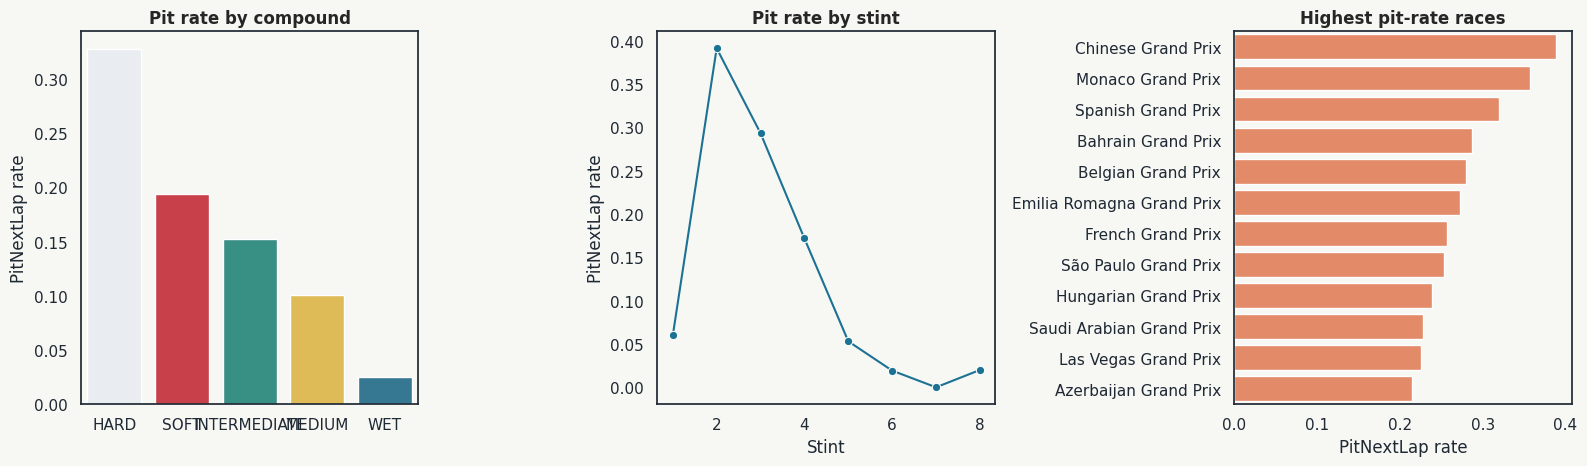

In [3]:
summary = pd.DataFrame({
    "rows": [len(train)],
    "races": [train["Race"].nunique()],
    "drivers": [train["Driver"].nunique()],
    "compounds": [train["Compound"].nunique()],
    "target_rate": [train[TARGET].mean()],
    "min_race_progress": [train["RaceProgress"].min()],
    "max_race_progress": [train["RaceProgress"].max()],
})
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

compound_rate = train.groupby("Compound", observed=True)[TARGET].agg(["mean", "count"]).sort_values("mean", ascending=False)
sns.barplot(x=compound_rate.index, y=compound_rate["mean"], ax=axes[0], palette=[compound_colors.get(str(x), "#999") for x in compound_rate.index])
axes[0].set_title("Pit rate by compound")
axes[0].set_ylabel("PitNextLap rate")
axes[0].set_xlabel("")

stint_rate = train.groupby("Stint", observed=True)[TARGET].agg(["mean", "count"]).reset_index()
sns.lineplot(data=stint_rate, x="Stint", y="mean", marker="o", ax=axes[1], color="#1c7293")
axes[1].set_title("Pit rate by stint")
axes[1].set_ylabel("PitNextLap rate")
axes[1].set_xlabel("Stint")

race_rate = train.groupby("Race", observed=True)[TARGET].agg(["mean", "count"]).sort_values("mean", ascending=False).head(12)
sns.barplot(x=race_rate["mean"], y=race_rate.index, ax=axes[2], color="#f78154")
axes[2].set_title("Highest pit-rate races")
axes[2].set_xlabel("PitNextLap rate")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

## Track Drawing Helpers

Each race gets a deterministic circuit avatar. The same race name always produces the same shape.

In [4]:
def stable_seed(text):
    digest = hashlib.md5(str(text).encode("utf-8")).hexdigest()
    return int(digest[:8], 16)


def circuit_path(name, n=900):
    rng = np.random.default_rng(stable_seed(name))
    theta = np.linspace(0, 2 * np.pi, n, endpoint=True)
    phases = rng.uniform(0, 2 * np.pi, 5)
    amps = rng.uniform(0.035, 0.14, 5)
    harmonics = np.array([2, 3, 4, 5, 7])
    r = 1.0
    for a, h, p in zip(amps, harmonics, phases):
        r = r + a * np.sin(h * theta + p)
    x = r * np.cos(theta)
    y = 0.68 * r * np.sin(theta)
    x += 0.08 * np.sin(3 * theta + phases[0])
    y += 0.06 * np.sin(5 * theta + phases[1])
    angle = rng.uniform(-0.55, 0.55)
    xr = x * np.cos(angle) - y * np.sin(angle)
    yr = x * np.sin(angle) + y * np.cos(angle)
    xr -= xr.mean()
    yr -= yr.mean()
    scale = max(np.ptp(xr), np.ptp(yr))
    xr /= scale
    yr /= scale
    return xr, yr


def progress_metric(df, value_col=TARGET, reducer="mean", bins=72, min_count=12):
    d = df[["RaceProgress", value_col]].copy()
    d["RaceProgress"] = pd.to_numeric(d["RaceProgress"], errors="coerce")
    d[value_col] = pd.to_numeric(d[value_col], errors="coerce")
    d = d.dropna()
    d["bin"] = pd.cut(d["RaceProgress"], np.linspace(0, 1, bins + 1), include_lowest=True)
    if reducer == "median":
        g = d.groupby("bin", observed=False)[value_col].agg(["median", "count"])
        values = g["median"].to_numpy(dtype=float)
    else:
        g = d.groupby("bin", observed=False)[value_col].agg(["mean", "count"])
        values = g["mean"].to_numpy(dtype=float)
    values[g["count"].to_numpy() < min_count] = np.nan
    centers = np.linspace(0.5 / bins, 1 - 0.5 / bins, bins)
    if np.all(np.isnan(values)):
        values[:] = 0.0
    else:
        ok = np.isfinite(values)
        values = np.interp(centers, centers[ok], values[ok])
    return centers, values


def draw_metric_track(ax, race_name, centers, values, cmap=pit_cmap, norm=None, lw=13, bg_lw=19, title=None, subtitle=None):
    x, y = circuit_path(race_name)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    progress = np.linspace(0, 1, len(segments))
    seg_values = np.interp(progress, centers, values)
    if norm is None:
        norm = Normalize(vmin=np.nanmin(values), vmax=np.nanmax(values))

    ax.add_collection(LineCollection(segments, colors="#1f2933", linewidths=bg_lw, capstyle="round", joinstyle="round", alpha=0.92))
    ax.add_collection(LineCollection(segments, colors="#f2f2ed", linewidths=max(lw + 4, 1), capstyle="round", joinstyle="round", alpha=1.0))
    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidths=lw, capstyle="round", joinstyle="round")
    lc.set_array(seg_values)
    ax.add_collection(lc)

    # Start-finish stripe and pit lane hint.
    ax.scatter([x[0]], [y[0]], s=80, marker="s", color="#ffffff", edgecolor="#111827", linewidth=1.5, zorder=5)
    ax.scatter([x[int(0.04 * len(x))]], [y[int(0.04 * len(y))]], s=34, marker="o", color="#111827", zorder=6)
    ax.text(x[0], y[0] + 0.07, "S/F", ha="center", va="bottom", fontsize=8, weight="bold")

    ax.set_aspect("equal")
    ax.set_xlim(x.min() - 0.16, x.max() + 0.16)
    ax.set_ylim(y.min() - 0.16, y.max() + 0.16)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=12, weight="bold", pad=8)
    if subtitle:
        ax.text(0.5, -0.05, subtitle, transform=ax.transAxes, ha="center", va="top", fontsize=9, color="#4b5563")
    return lc


def add_colorbar(fig, mappable, ax, label):
    cb = fig.colorbar(mappable, ax=ax, fraction=0.045, pad=0.02)
    cb.set_label(label)
    return cb

## Pit Risk On A Stylized Racing Line

The color around each track shows empirical `PitNextLap` rate by race-progress bin.

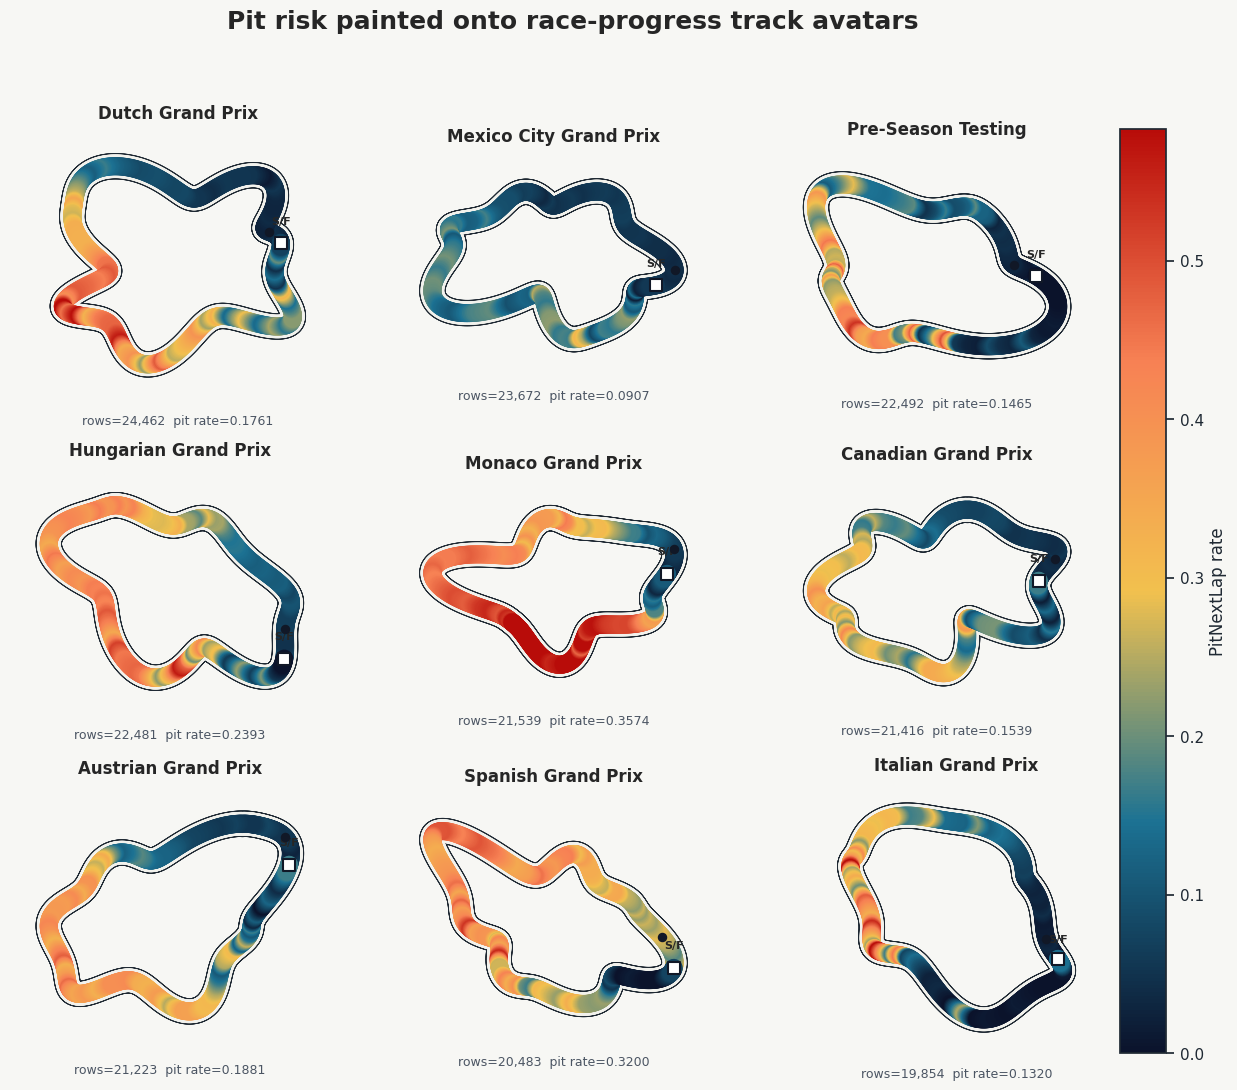

In [5]:
top_races = train["Race"].value_counts().head(9).index.tolist()
all_values = []
for race in top_races:
    _, vals = progress_metric(train[train["Race"] == race], TARGET, bins=72, min_count=8)
    all_values.append(vals)
track_norm = Normalize(vmin=0, vmax=np.nanpercentile(np.concatenate(all_values), 98))

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
last_lc = None
for ax, race in zip(axes.ravel(), top_races):
    d = train[train["Race"] == race]
    centers, vals = progress_metric(d, TARGET, bins=72, min_count=8)
    last_lc = draw_metric_track(
        ax, race, centers, vals, cmap=pit_cmap, norm=track_norm,
        title=str(race), subtitle=f"rows={len(d):,}  pit rate={d[TARGET].mean():.4f}"
    )
fig.suptitle("Pit risk painted onto race-progress track avatars", fontsize=18, weight="bold", y=0.98)
add_colorbar(fig, last_lc, axes.ravel().tolist(), "PitNextLap rate")
plt.show()

## Compound Racing Lines

For a selected race, each compound gets its own line. The line shape is the same circuit avatar; color shows where that compound is more likely to pit next lap.

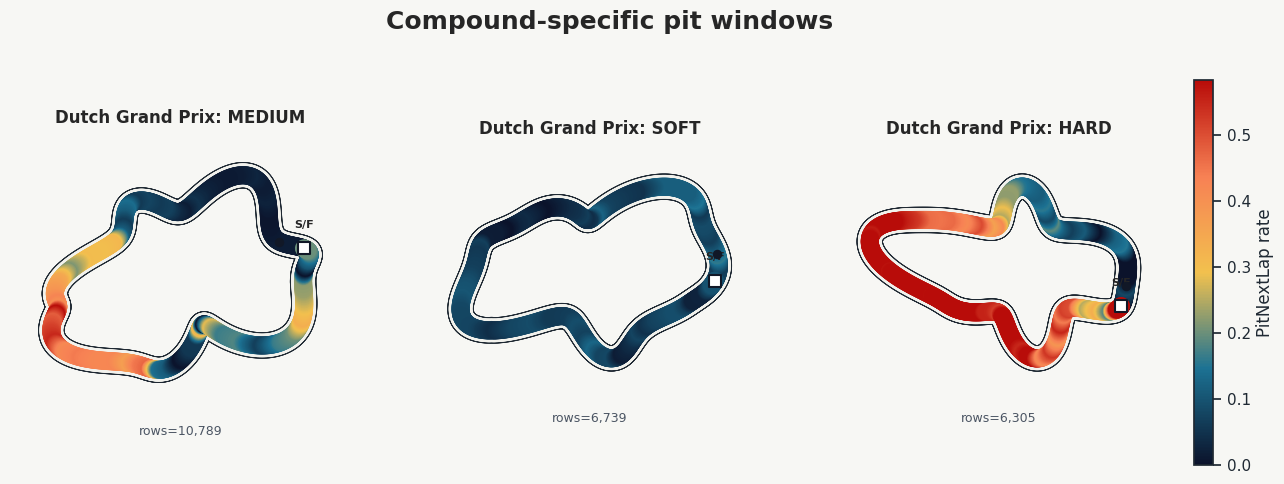

In [6]:
selected_race = top_races[0]
fig, axes = plt.subplots(1, min(3, len(compound_colors)), figsize=(16, 5))
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

race_df = train[train["Race"] == selected_race]
used_compounds = [c for c in race_df["Compound"].value_counts().index if c in set(train["Compound"])]
used_compounds = used_compounds[:len(axes)]
for ax, comp in zip(axes, used_compounds):
    d = race_df[race_df["Compound"] == comp]
    centers, vals = progress_metric(d, TARGET, bins=64, min_count=5)
    lc = draw_metric_track(
        ax, f"{selected_race}_{comp}", centers, vals,
        cmap=pit_cmap, norm=track_norm,
        title=f"{selected_race}: {comp}", subtitle=f"rows={len(d):,}"
    )
fig.suptitle("Compound-specific pit windows", fontsize=18, weight="bold", y=1.02)
add_colorbar(fig, lc, axes.tolist(), "PitNextLap rate")
plt.show()

## Tyre Age Around The Track

The same circuit style can show other race-state quantities. Here the color is median tyre life by race-progress bin.

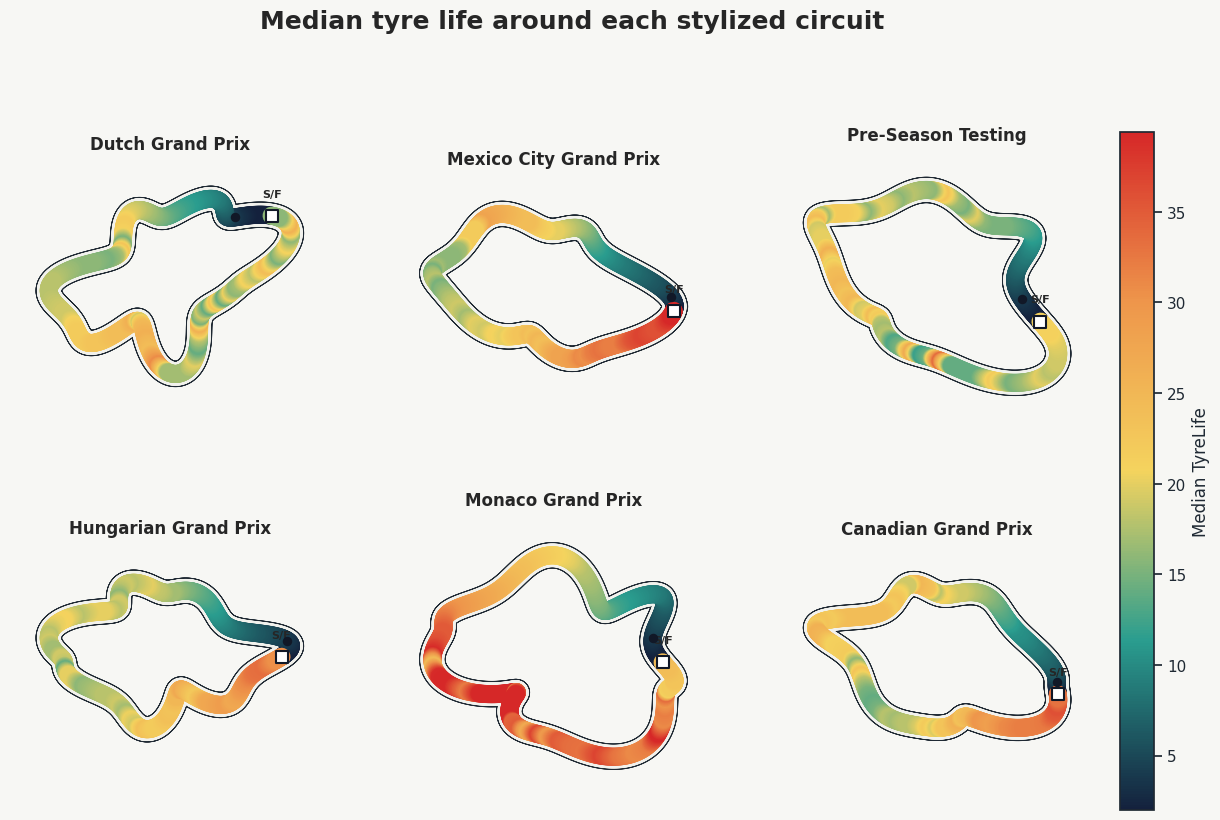

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8.8))
races = top_races[:6]
all_tyre = []
for race in races:
    _, vals = progress_metric(train[train["Race"] == race], "TyreLife", reducer="median", bins=72, min_count=8)
    all_tyre.append(vals)
tyre_norm = Normalize(vmin=np.nanpercentile(np.concatenate(all_tyre), 2), vmax=np.nanpercentile(np.concatenate(all_tyre), 98))

last_lc = None
for ax, race in zip(axes.ravel(), races):
    d = train[train["Race"] == race]
    centers, vals = progress_metric(d, "TyreLife", reducer="median", bins=72, min_count=8)
    last_lc = draw_metric_track(ax, race + " tyre", centers, vals, cmap=tyre_cmap, norm=tyre_norm, title=str(race))
fig.suptitle("Median tyre life around each stylized circuit", fontsize=18, weight="bold", y=1.02)
add_colorbar(fig, last_lc, axes.ravel().tolist(), "Median TyreLife")
plt.show()

## Pit Stops As Trackside Flags

This view draws the racing line in gray, then places red flags at the highest-risk race-progress bins.

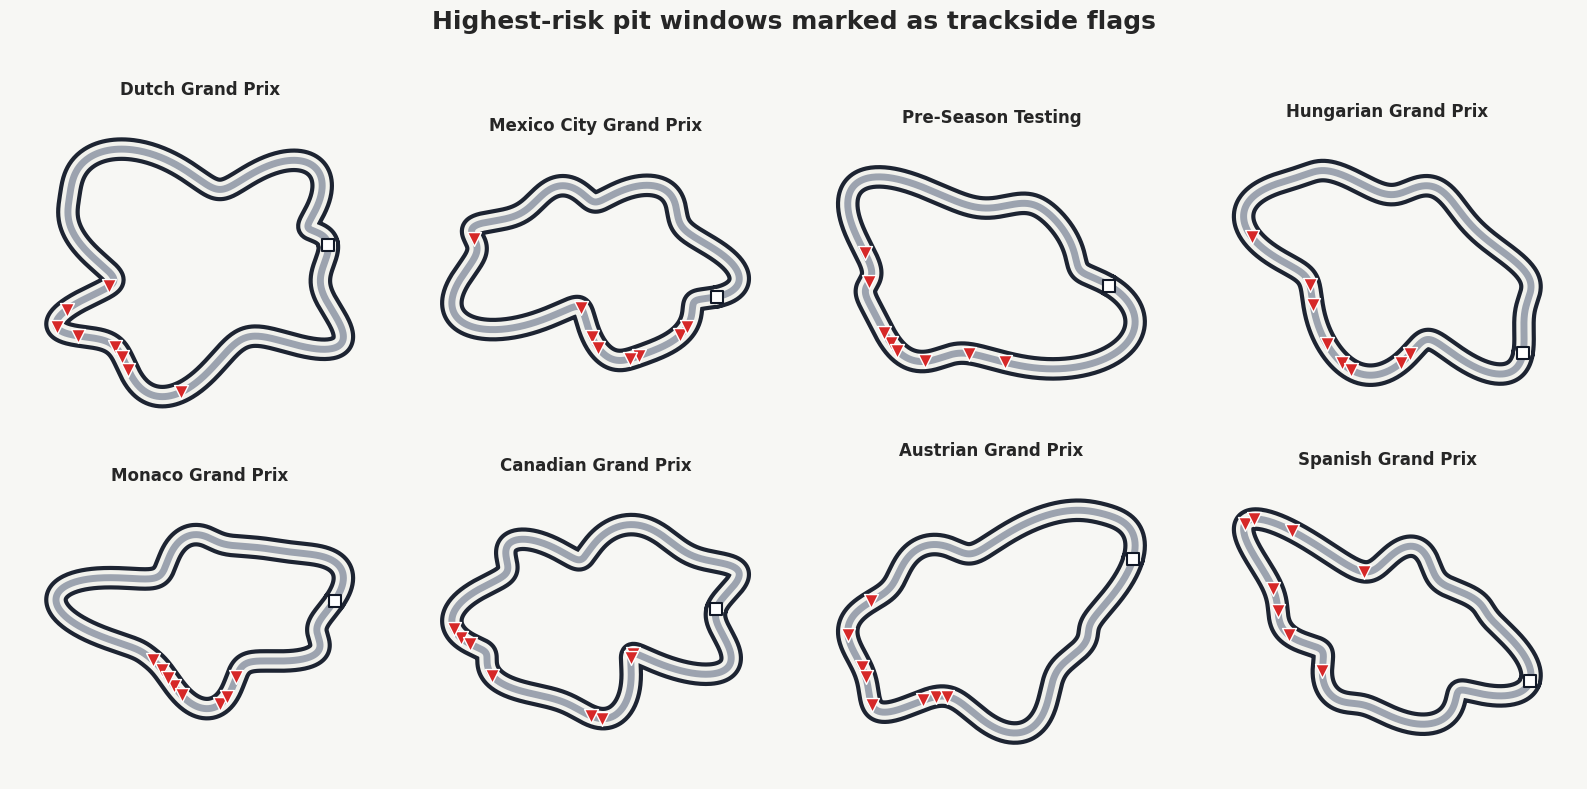

In [8]:
def draw_flag_track(ax, race_name, df, bins=72, top_k=8):
    centers, vals = progress_metric(df, TARGET, bins=bins, min_count=8)
    x, y = circuit_path(race_name)
    ax.plot(x, y, color="#111827", lw=17, solid_capstyle="round", alpha=0.95)
    ax.plot(x, y, color="#f2f2ed", lw=11, solid_capstyle="round", alpha=1.0)
    ax.plot(x, y, color="#9ca3af", lw=5, solid_capstyle="round", alpha=1.0)
    best = np.argsort(vals)[-top_k:]
    for b in best:
        idx = int(np.clip(centers[b] * (len(x) - 1), 0, len(x) - 1))
        ax.scatter(x[idx], y[idx], s=100, marker="v", color="#d62828", edgecolor="white", linewidth=1.0, zorder=4)
    ax.scatter([x[0]], [y[0]], s=80, marker="s", color="#ffffff", edgecolor="#111827", linewidth=1.5, zorder=5)
    ax.set_title(str(race_name), fontsize=12, weight="bold")
    ax.set_aspect("equal")
    ax.set_xlim(x.min() - 0.16, x.max() + 0.16)
    ax.set_ylim(y.min() - 0.16, y.max() + 0.16)
    ax.axis("off")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, race in zip(axes.ravel(), top_races[:8]):
    draw_flag_track(ax, race, train[train["Race"] == race])
fig.suptitle("Highest-risk pit windows marked as trackside flags", fontsize=18, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Classic EDA, Track-Day Style

A few standard summaries help interpret the circuit maps.

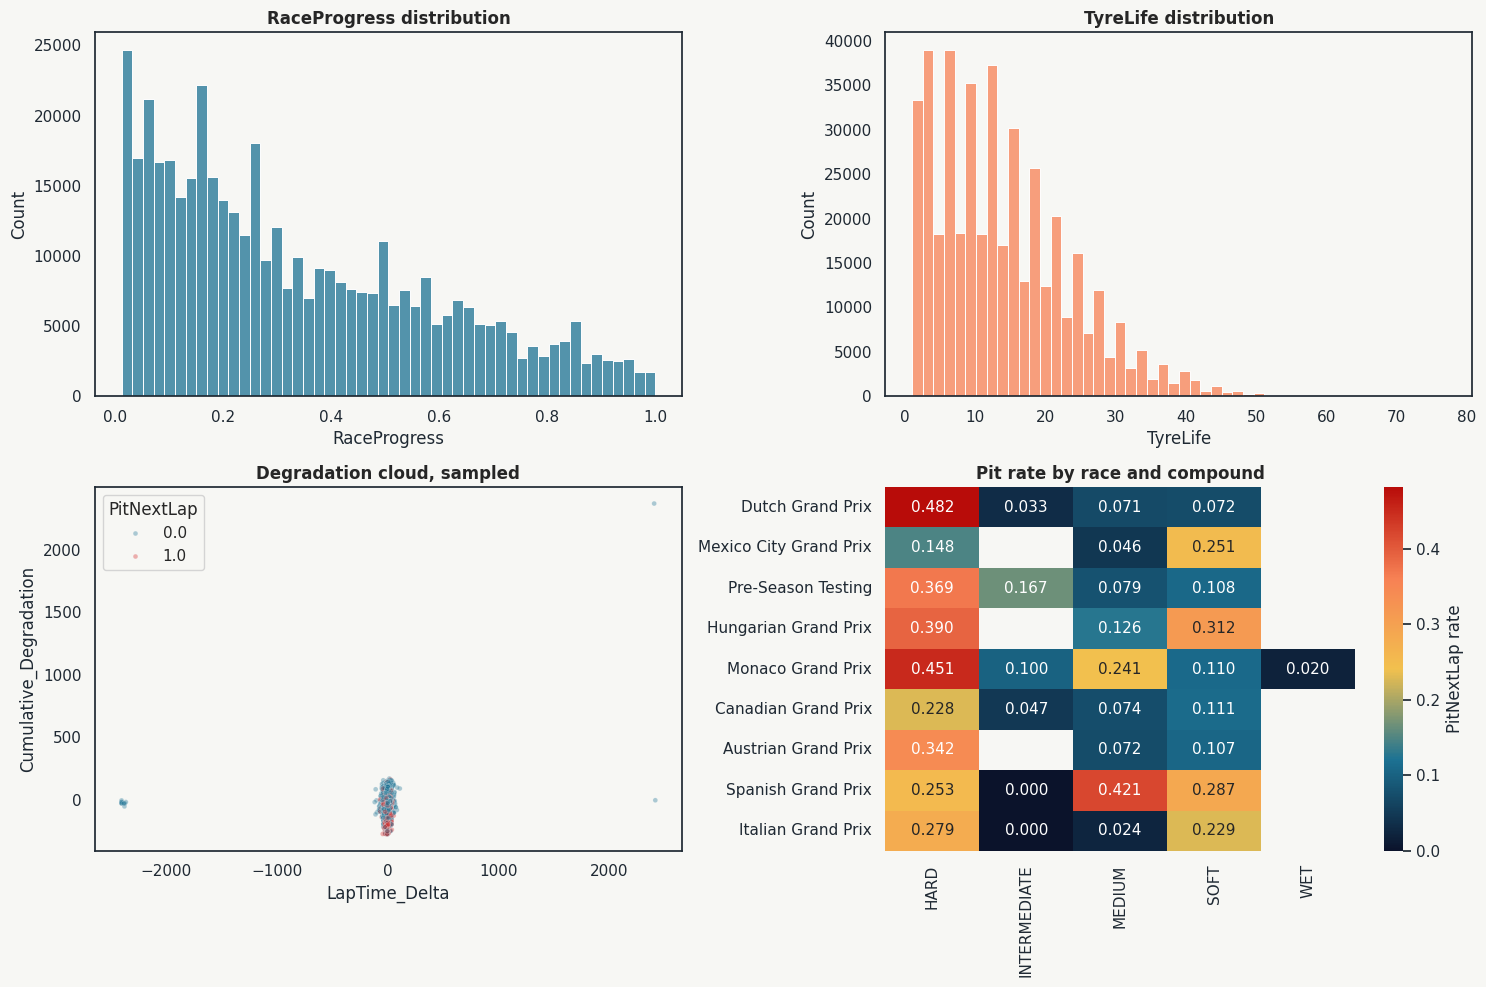

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(train["RaceProgress"], bins=50, ax=axes[0, 0], color="#1c7293")
axes[0, 0].set_title("RaceProgress distribution")

sns.histplot(train["TyreLife"], bins=50, ax=axes[0, 1], color="#f78154")
axes[0, 1].set_title("TyreLife distribution")

sns.scatterplot(
    data=train.sample(min(len(train), 30000), random_state=42),
    x="LapTime_Delta", y="Cumulative_Degradation", hue=TARGET,
    palette={0: "#1c7293", 1: "#d62828"}, alpha=0.35, s=12, ax=axes[1, 0]
)
axes[1, 0].set_title("Degradation cloud, sampled")
axes[1, 0].legend(title=TARGET)

race_comp = train.groupby(["Race", "Compound"], observed=True)[TARGET].mean().reset_index()
pivot = race_comp.pivot(index="Race", columns="Compound", values=TARGET).loc[top_races]
sns.heatmap(pivot, cmap=pit_cmap, annot=True, fmt=".3f", ax=axes[1, 1], cbar_kws={"label": "PitNextLap rate"})
axes[1, 1].set_title("Pit rate by race and compound")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()

## One-Race Dashboard

Pick one race and see its pit-risk track, tyre-life track, compound mix, and pit-rate curve together.

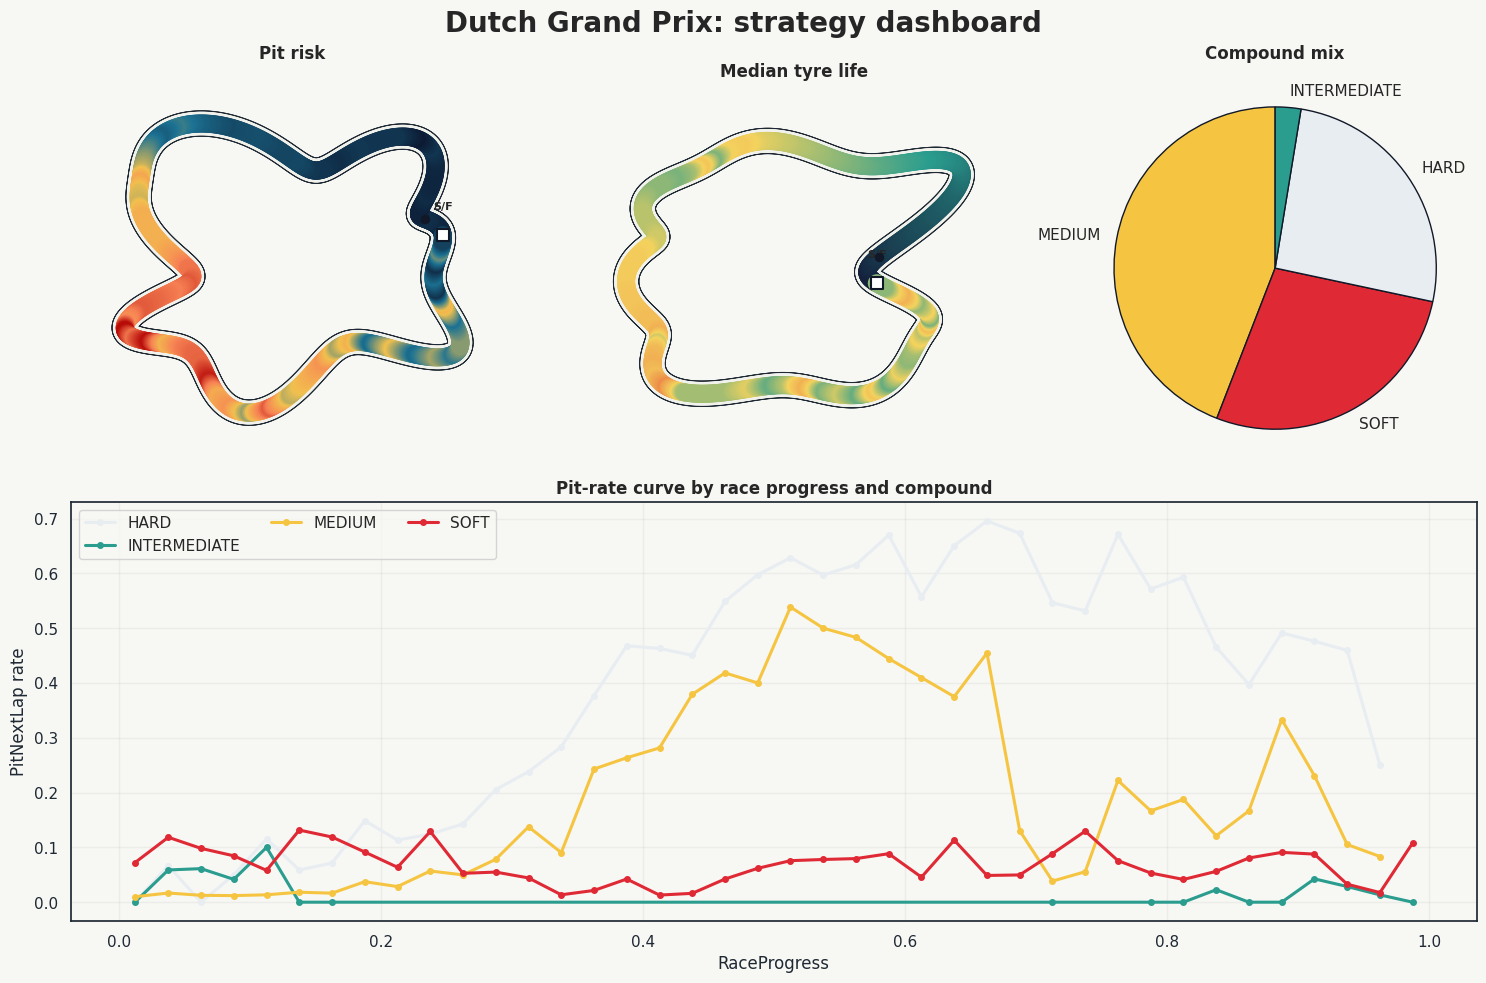

In [10]:
race_to_view = top_races[0]
d = train[train["Race"] == race_to_view].copy()
fig = plt.figure(figsize=(15, 10))
grid = fig.add_gridspec(2, 3, width_ratios=[1.1, 1.1, 1.0], height_ratios=[1.0, 1.0])

ax1 = fig.add_subplot(grid[0, 0])
centers, vals = progress_metric(d, TARGET, bins=72, min_count=8)
lc1 = draw_metric_track(ax1, race_to_view, centers, vals, cmap=pit_cmap, norm=track_norm, title="Pit risk")

ax2 = fig.add_subplot(grid[0, 1])
centers, vals = progress_metric(d, "TyreLife", reducer="median", bins=72, min_count=8)
lc2 = draw_metric_track(ax2, race_to_view + " dash", centers, vals, cmap=tyre_cmap, norm=tyre_norm, title="Median tyre life")

ax3 = fig.add_subplot(grid[0, 2])
compound_counts = d["Compound"].value_counts()
colors = [compound_colors.get(str(c), "#999") for c in compound_counts.index]
ax3.pie(compound_counts.values, labels=compound_counts.index, colors=colors, startangle=90, wedgeprops={"edgecolor": "#111827", "linewidth": 1})
ax3.set_title("Compound mix", weight="bold")

ax4 = fig.add_subplot(grid[1, :])
curve = d.copy()
curve["progress_bin"] = pd.cut(curve["RaceProgress"], np.linspace(0, 1, 41), include_lowest=True)
g = curve.groupby(["progress_bin", "Compound"], observed=True)[TARGET].agg(["mean", "count"]).reset_index()
g = g[g["count"] >= 8]
g["progress_mid"] = g["progress_bin"].apply(lambda iv: float((iv.left + iv.right) / 2))
for comp in g["Compound"].unique():
    gg = g[g["Compound"] == comp]
    ax4.plot(gg["progress_mid"], gg["mean"], marker="o", lw=2.2, ms=4, label=comp, color=compound_colors.get(str(comp)))
ax4.set_title("Pit-rate curve by race progress and compound", weight="bold")
ax4.set_xlabel("RaceProgress")
ax4.set_ylabel("PitNextLap rate")
ax4.legend(ncol=3)
ax4.grid(alpha=0.25)

fig.suptitle(f"{race_to_view}: strategy dashboard", fontsize=20, weight="bold", y=0.98)
plt.tight_layout()
plt.show()

## Takeaways

The track-style views turn ordinary tabular EDA into a race-progress map:

- `RaceProgress` acts like position around a lap-distance circuit.
- The red/orange segments are empirical pit windows.
- Different compounds create different pit-risk shapes.
- Tyre age and degradation help explain why the high-risk sections appear.

The circuit drawings are stylized avatars, but the colors and summaries come directly from the competition data.